# 2.1. Points, lines, polygons and grids

Recreates the "2.1. Points, lines, polygons and grids" figures from the R
package's README, using `create_points`, `create_lines`, `create_polys`,
`create_polygrids` and `add_colour`. Runs entirely offline: the coastline
overlays below use the bundled `datasets.load_example("Coast")` (same data
`clip_to_coast()` defaults to), not the live WFS.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import ccamlrgis as cg
import ccamlrgis.plot as cgplot
from ccamlrgis import datasets

point_data = datasets.load_example("PointData")
line_data = datasets.load_example("LineData")
poly_data = datasets.load_example("PolyData")
grid_data = datasets.load_example("GridData")
coast = datasets.load_example("Coast")
coast_all = coast[coast["ID"] == "All"]

## Create points

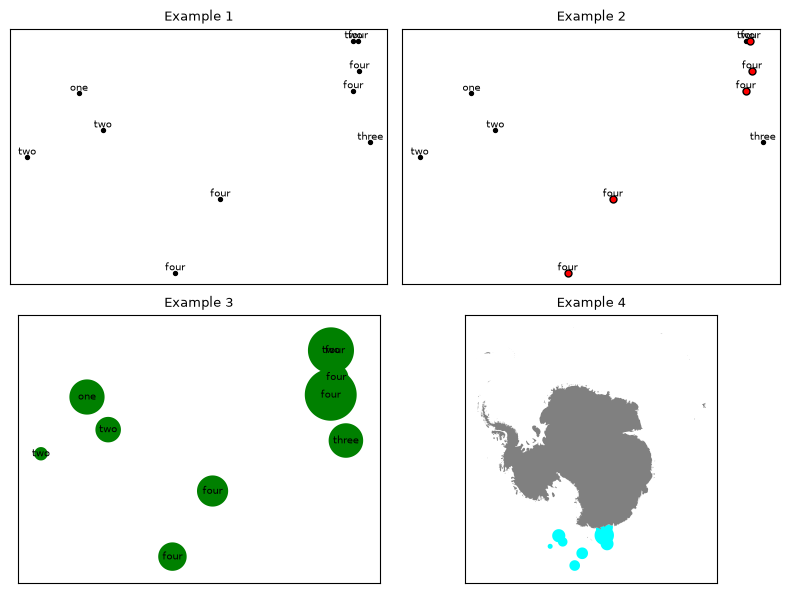

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# Example 1: simple points with labels
pts = cg.create_points(point_data)
ax = cgplot.basemap(ax=axes[0, 0])[1]
pts.plot(ax=ax, markersize=8, color="black")
for _, row in pts.iterrows():
    ax.annotate(row["name"], (row["x"], row["y"]), ha="center", va="bottom", fontsize=7)
ax.set_title("Example 1", fontsize=9)

# Example 2: highlight one group of points
pts = cg.create_points(point_data)
ax = cgplot.basemap(ax=axes[0, 1])[1]
pts.plot(ax=ax, markersize=8, color="black")
for _, row in pts.iterrows():
    ax.annotate(row["name"], (row["x"], row["y"]), ha="center", va="bottom", fontsize=7)
pts[pts["name"] == "four"].plot(ax=ax, markersize=25, color="red", edgecolor="black")
ax.set_title("Example 2", fontsize=9)

# Example 3: buffered points, radius proportional to catch
pts = cg.create_points(point_data, buffer=1 * point_data["Catch"])
ax = cgplot.basemap(ax=axes[1, 0])[1]
pts.plot(ax=ax, color="green")
for _, row in pts.iterrows():
    ax.annotate(row["name"], (row["x"], row["y"]), ha="center", va="center", fontsize=7)
ax.set_title("Example 3", fontsize=9)

# Example 4: buffered points clipped to the coast
pts = cg.create_points(point_data, buffer=2 * point_data["Catch"], clip=True)
ax = cgplot.basemap(ax=axes[1, 1])[1]
pts.plot(ax=ax, color="cyan")
coast_all.plot(ax=ax, color="grey", linewidth=0.5)
ax.set_title("Example 4", fontsize=9)

fig.tight_layout()
plt.show()

## Create lines

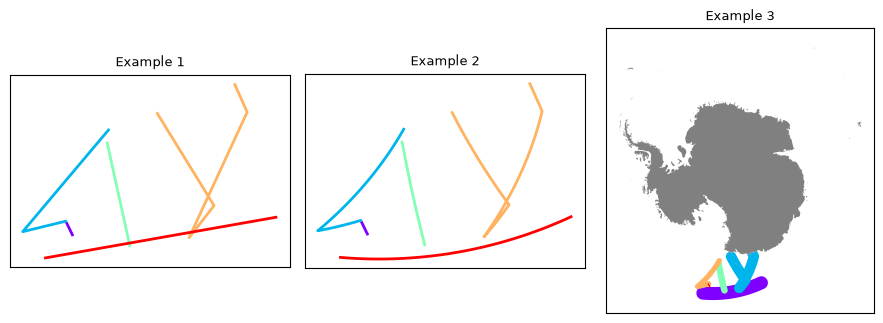

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))

# Example 1: simple, non-densified lines
lines = cg.create_lines(line_data)
ax = cgplot.basemap(ax=axes[0])[1]
lines.plot(ax=ax, cmap="rainbow", linewidth=2)
ax.set_title("Example 1", fontsize=9)

# Example 2: densified lines (note the curvature)
lines = cg.create_lines(line_data, densify=True)
ax = cgplot.basemap(ax=axes[1])[1]
lines.plot(ax=ax, cmap="rainbow", linewidth=2)
ax.set_title("Example 2", fontsize=9)

# Example 3: densified, buffered and clipped lines
lines = cg.create_lines(line_data, densify=True, buffer=[10, 40, 50, 80, 100], clip=True)
ax = cgplot.basemap(ax=axes[2])[1]
lines.iloc[::-1].plot(ax=ax, cmap="rainbow", linewidth=1)
coast_all.plot(ax=ax, color="grey", linewidth=0.5)
ax.set_title("Example 3", fontsize=9)

fig.tight_layout()
plt.show()

Adding a buffer with `separate_buffers=False` results in a single
polygon which may be viewed as a footprint:

Buffered_AreaKm2: 222654.8


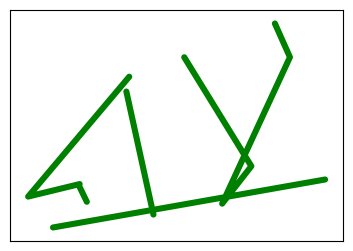

In [4]:
merged = cg.create_lines(line_data, buffer=10, separate_buffers=False)
print("Buffered_AreaKm2:", merged["Buffered_AreaKm2"].iloc[0])

fig, ax = plt.subplots(figsize=(5, 3))
cgplot.basemap(ax=ax)
merged.plot(ax=ax, color="green")
plt.show()

## Create polygons

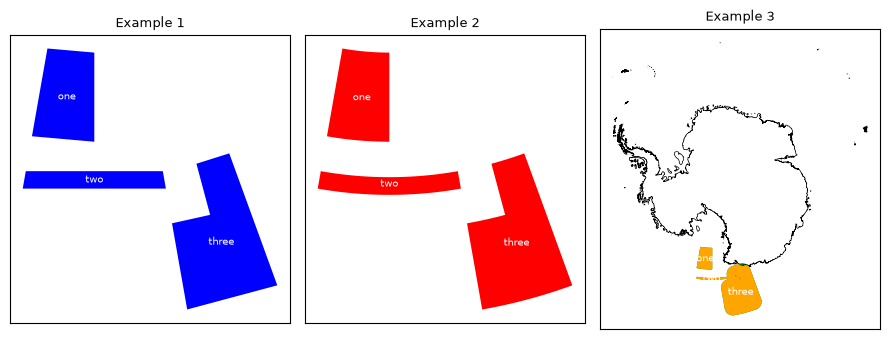

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3.6))

# Example 1: simple, non-densified polygons
polys = cg.create_polys(poly_data, densify=False)
ax = cgplot.basemap(ax=axes[0])[1]
polys.plot(ax=ax, color="blue")
for _, row in polys.iterrows():
    ax.annotate(row["ID"], (row["Labx"], row["Laby"]), ha="center", va="center", color="white", fontsize=7)
ax.set_title("Example 1", fontsize=9)

# Example 2: simple, densified polygons (note the curvature)
polys = cg.create_polys(poly_data)
ax = cgplot.basemap(ax=axes[1])[1]
polys.plot(ax=ax, color="red")
for _, row in polys.iterrows():
    ax.annotate(row["ID"], (row["Labx"], row["Laby"]), ha="center", va="center", color="white", fontsize=7)
ax.set_title("Example 2", fontsize=9)

# Example 3: buffered and clipped polygons
polys_before = cg.create_polys(poly_data, buffer=[10, -15, 120])
polys_after = cg.create_polys(poly_data, buffer=[10, -15, 120], clip=True)
ax = cgplot.basemap(ax=axes[2])[1]
polys_before.plot(ax=ax, color="green")
coast_all.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)
polys_after.plot(ax=ax, color="orange")
for _, row in polys_after.iterrows():
    ax.annotate(row["ID"], (row["Labx"], row["Laby"]), ha="center", va="center", color="white", fontsize=7)
ax.set_title("Example 3", fontsize=9)

fig.tight_layout()
plt.show()

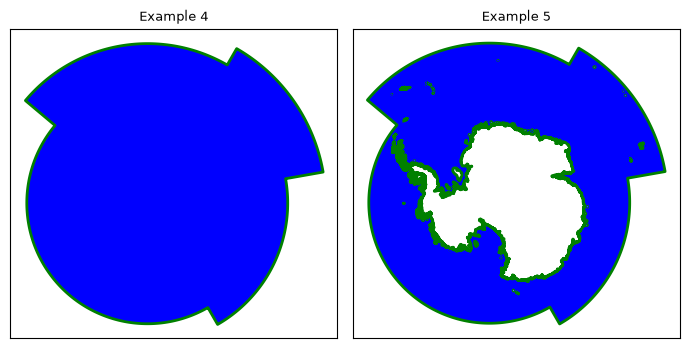

In [6]:
# Convention area: vertices given clockwise, starting from the NW corner of 48.3
ca = pd.DataFrame({
    "Name": ["CA"] * 8,
    "Lat": [-50, -50, -45, -45, -55, -55, -60, -60],
    "Lon": [-50, 30, 30, 80, 80, 150, 150, -50],
})

fig, axes = plt.subplots(1, 2, figsize=(7, 4))

# Example 4: Convention area contour
ca_poly = cg.create_polys(ca)
ax = cgplot.basemap(ax=axes[0])[1]
ca_poly.plot(ax=ax, color="blue", edgecolor="green", linewidth=2)
ax.set_title("Example 4", fontsize=9)

# Example 5: Convention area contour, coastline-clipped
ca_poly_clip = cg.create_polys(ca, clip=True)
ax = cgplot.basemap(ax=axes[1])[1]
ca_poly_clip.plot(ax=ax, color="blue", edgecolor="green", linewidth=2)
ax.set_title("Example 5", fontsize=9)

fig.tight_layout()
plt.show()

## Create grids

An advanced demo is given in `notebooks/` (Advanced Grids, ported from
`Advanced_Grids/Advanced_Grids.md`).

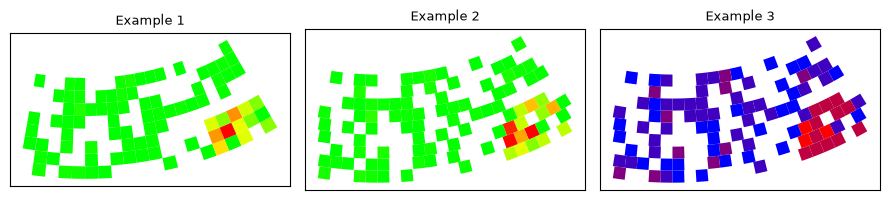

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

# Example 1: simple grid, automatic colours
grid = cg.create_polygrids(grid_data, dlon=2, dlat=1)
ax = cgplot.basemap(ax=axes[0])[1]
grid.plot(ax=ax, color=grid["Col_Catch_sum"], linewidth=0.1)
ax.set_title("Example 1", fontsize=9)

# Example 2: equal-area grid, automatic colours
grid = cg.create_polygrids(grid_data, area=10000)
ax = cgplot.basemap(ax=axes[1])[1]
grid.plot(ax=ax, color=grid["Col_Catch_sum"], linewidth=0.1)
ax.set_title("Example 2", fontsize=9)

# Example 3: equal-area grid, custom cuts and colours
grid = cg.create_polygrids(grid_data, area=10000, cuts=[0, 50, 100, 500, 2000, 3500], cols=["blue", "red"])
ax = cgplot.basemap(ax=axes[2])[1]
grid.plot(ax=ax, color=grid["Col_Catch_sum"], linewidth=0.1)
ax.set_title("Example 3", fontsize=9)

fig.tight_layout()
plt.show()

Customizing a grid and adding a colour scale:

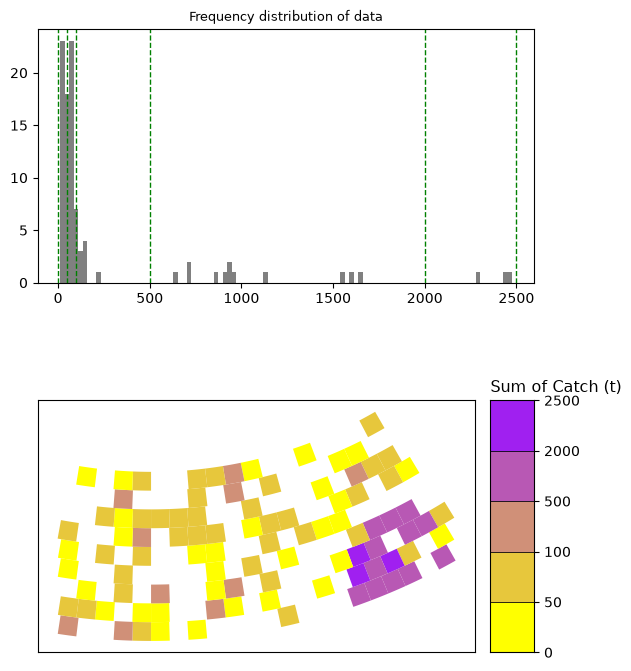

In [8]:
# Step 1: generate the grid
grid = cg.create_polygrids(grid_data, area=10000)

# Step 2: inspect the gridded data to decide whether irregular cuts are needed
my_cuts = [0, 50, 100, 500, 2000, 2500]

fig, (ax_hist, ax_map) = plt.subplots(2, 1, figsize=(6, 8), gridspec_kw={"height_ratios": [1, 2]})
ax_hist.hist(grid["Catch_sum"], bins=100, color="grey")
for c in my_cuts:
    ax_hist.axvline(c, color="green", linestyle="--", linewidth=1)
ax_hist.set_title("Frequency distribution of data", fontsize=9)

# Step 3: generate colours for the desired classes
grid_col = cg.add_colour(grid["Catch_sum"], cuts=my_cuts, cols=["yellow", "purple"])

# Step 4: plot the result and add a colour scale
cgplot.basemap(ax=ax_map)
grid.plot(ax=ax_map, color=grid_col["varcol"], linewidth=0.1)
cgplot.add_colour_scale(ax=ax_map, cuts=grid_col["cuts"], cols=grid_col["cols"], title="Sum of Catch (t)", size="10%")

fig.tight_layout()
plt.show()